# Indonesia AI Usage vs. US Observed Exposure

**The core question:** For each occupation, how does Indonesia's actual Claude usage compare to the US-measured AI exposure (Massenkoff & McCrory 2026)?

**Two variables, both measured:**
- **X-axis:** `observed_exposure` — US-derived AI exposure per occupation
- **Y-axis:** Indonesia's share of Claude usage attributable to that occupation

**What the shape tells you:**
- Upper-right: Indonesia already uses AI in occupations that are highly exposed → the observable adjustment cohort
- Lower-right: High exposure but low Indonesian usage → latent displacement risk
- Upper-left: Indonesia uses AI in low-exposure occupations → augmentation, not displacement
- Spearman correlation between the two variables is the headline statistic

**Prerequisite:** Run `aei_indonesia_diagnostic.ipynb` first so `aei_data/` exists.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from pathlib import Path
from huggingface_hub import hf_hub_download
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

REPO_ID = 'Anthropic/EconomicIndex'
RELEASE = 'release_2025_09_15'
AEI_DIR = Path('./aei_data')
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

INDONESIA = 'ID'  # ISO-2 code

print('Setup complete.')

Setup complete.


## 1. Load all data

In [2]:
# Download any missing files
files_needed = [
    f'{RELEASE}/data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv',
    f'{RELEASE}/data/intermediate/working_age_pop_2024_country.csv',
    f'{RELEASE}/data/intermediate/onet_task_statements.csv',
]
for f in files_needed:
    try:
        hf_hub_download(repo_id=REPO_ID, filename=f, repo_type='dataset', local_dir=AEI_DIR)
    except Exception as e:
        print(f'Failed to download {f}: {e}')

# Load
geo_raw = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv')
pop = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/working_age_pop_2024_country.csv')
onet_tasks = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/onet_task_statements.csv')
job_exposure = pd.read_csv('job_exposure.csv')  # local from Massenkoff & McCrory

print(f'geo_raw:      {geo_raw.shape}')
print(f'pop:          {pop.shape}')
print(f'onet_tasks:   {onet_tasks.shape}')
print(f'job_exposure: {job_exposure.shape}')

# Show what variables exist per facet so we know what to filter on
print('\nVariables available per facet:')
print(geo_raw.groupby('facet').variable.unique().apply(lambda x: list(x)))

geo_raw:      (100062, 10)
pop:          (194, 5)
onet_tasks:   (19530, 9)
job_exposure: (756, 3)

Variables available per facet:
facet
collaboration                        [collaboration_count, collaboration_pct]
country                                              [usage_count, usage_pct]
onet_task                                    [onet_task_count, onet_task_pct]
onet_task::collaboration    [onet_task_collaboration_count, onet_task_coll...
request                                          [request_count, request_pct]
request::collaboration      [request_collaboration_count, request_collabor...
state_us                                             [usage_count, usage_pct]
Name: variable, dtype: object


## 2. Indonesia's AUI (quick context number)

Not the focus of this analysis, but useful to report as context.

In [3]:
# Get country-level usage share: facet=country, variable=usage_pct
country_usage = (
    geo_raw[(geo_raw.facet == 'country') & (geo_raw.variable == 'usage_pct')]
    [['geo_id', 'value']].rename(columns={'value': 'usage_pct'})
)

# Join with working-age population share
pop_clean = pop[['country_code', 'working_age_pop']].rename(columns={'country_code': 'geo_id'}).dropna()
pop_clean['pop_share'] = 100 * pop_clean.working_age_pop / pop_clean.working_age_pop.sum()

aui = country_usage.merge(pop_clean, on='geo_id')
aui['AUI'] = aui.usage_pct / aui.pop_share

id_aui = aui[aui.geo_id == INDONESIA].AUI.values[0]
median_aui = aui.AUI.median()

print(f'Indonesia AUI:    {id_aui:.3f}')
print(f'Global median:    {median_aui:.3f}')
print(f'Indonesia is at  {id_aui / median_aui:.0%} of the global median adoption rate')

Indonesia AUI:    0.368
Global median:    0.757
Indonesia is at  49% of the global median adoption rate


## 3. Extract Indonesia's task-level AI usage

Each facet in the AEI data uses its own variable naming scheme. For the `onet_task` facet it's `onet_task_pct`, not the generic `usage_pct`.

In [4]:
# Find the percentage variable used by the onet_task facet
onet_vars = geo_raw[geo_raw.facet == 'onet_task'].variable.unique()
task_pct_var = next((v for v in onet_vars if 'pct' in v.lower()), None)
print(f'Variables in onet_task facet: {list(onet_vars)}')
print(f'Using: {task_pct_var}')

task_usage = (
    geo_raw[(geo_raw.facet == 'onet_task') & (geo_raw.variable == task_pct_var)]
    [['geo_id', 'cluster_name', 'value']]
    .rename(columns={'value': 'usage_pct', 'cluster_name': 'task'})
)

id_tasks = task_usage[task_usage.geo_id == INDONESIA].copy()
print(f'\nIndonesia O*NET tasks observed: {len(id_tasks)}')
print(f'Total usage_pct covered:         {id_tasks.usage_pct.sum():.1f}%')

# Show the top 10 for context
print('\nTop 10 Indonesian AI tasks by usage share:')
for _, r in id_tasks.nlargest(10, 'usage_pct').iterrows():
    print(f'  {r.usage_pct:5.2f}%  {r.task[:85]}')

Variables in onet_task facet: ['onet_task_count', 'onet_task_pct']
Using: onet_task_pct

Indonesia O*NET tasks observed: 170
Total usage_pct covered:         200.0%

Top 10 Indonesian AI tasks by usage share:
  88.47%  not_classified
  25.61%  not_classified
   5.77%  none
   5.37%  write new programs or modify existing programs to meet customer requirements, using c
   4.50%  modify existing software to correct errors, allow it to adapt to new hardware, or to 
   4.12%  assist students who need extra help with their coursework outside of class.
   3.48%  modify existing software to correct errors, to adapt it to new hardware, or to upgrad
   3.11%  develop instructional materials to be used by educators and instructors.
   2.97%  diagnose, troubleshoot, and resolve hardware, software, or other network and system p
   2.85%  none


## 4. Map Indonesia's tasks to occupations

Join the AEI task descriptions to O\*NET task statements (which carry SOC codes), then aggregate Indonesian usage to the occupation level.

In [5]:
# Identify task-text and SOC columns in onet_tasks
task_col = next((c for c in onet_tasks.columns if 'task' in c.lower() and onet_tasks[c].dtype == 'object'), None)
soc_col = next((c for c in onet_tasks.columns if 'onet' in c.lower() or 'soc' in c.lower()), None)
print(f'Task column: {task_col}')
print(f'SOC column:  {soc_col}')

# Normalize task text the same way AEI normalized it (lowercase, no trailing period)
normalize = lambda s: str(s).strip().lower().rstrip('.')
onet_tasks['task_norm'] = onet_tasks[task_col].apply(normalize)
onet_tasks['occ_code'] = onet_tasks[soc_col].astype(str).str.split('.').str[0]
id_tasks['task_norm'] = id_tasks.task.apply(normalize)

# Join
id_with_occ = id_tasks.merge(
    onet_tasks[['task_norm', 'occ_code']].drop_duplicates('task_norm'),
    on='task_norm', how='left'
)

matched = id_with_occ.occ_code.notna().sum()
print(f'\nIndonesia tasks matched to occupations: {matched} / {len(id_with_occ)}  ({matched/len(id_with_occ):.0%})')

Task column: Task
SOC column:  O*NET-SOC Code

Indonesia tasks matched to occupations: 166 / 170  (98%)


In [6]:
# Aggregate Indonesia's AI usage to the occupation level, then join with observed exposure
id_by_occ = (
    id_with_occ.dropna(subset=['occ_code'])
    .groupby('occ_code', as_index=False)
    .agg(indonesia_usage_pct=('usage_pct', 'sum'),
         n_tasks=('task', 'count'))
)

# Full merge with job_exposure: include occupations even if Indonesia has zero usage
df = job_exposure.merge(id_by_occ, on='occ_code', how='left')
df['indonesia_usage_pct'] = df.indonesia_usage_pct.fillna(0)
df['n_tasks'] = df.n_tasks.fillna(0).astype(int)

print(f'Total US occupations: {len(df)}')
print(f'With Indonesian usage: {(df.indonesia_usage_pct > 0).sum()}')
print(f'With exposure > 0:     {(df.observed_exposure > 0).sum()}')
print(f'With both > 0:         {((df.indonesia_usage_pct > 0) & (df.observed_exposure > 0)).sum()}')

Total US occupations: 756
With Indonesian usage: 72
With exposure > 0:     345
With both > 0:         68


## 5. The main result: scatter + correlation

The simplest possible framing — two axes, both measured, one point per occupation.

In [7]:
# Compute correlations on the subset where both variables have signal
both_nonzero = df[(df.indonesia_usage_pct > 0) & (df.observed_exposure > 0)].copy()
all_positive_exposure = df[df.observed_exposure > 0].copy()

sp_both, sp_both_p = spearmanr(both_nonzero.observed_exposure, both_nonzero.indonesia_usage_pct)
sp_all, sp_all_p = spearmanr(all_positive_exposure.observed_exposure, all_positive_exposure.indonesia_usage_pct)

pr_both, pr_both_p = pearsonr(both_nonzero.observed_exposure, both_nonzero.indonesia_usage_pct)

print('=== CORRELATIONS ===\n')
print(f'Occupations with BOTH nonzero (n={len(both_nonzero)}):')
print(f'  Spearman rho: {sp_both:+.3f}  (p={sp_both_p:.4f})')
print(f'  Pearson  r:   {pr_both:+.3f}  (p={pr_both_p:.4f})')
print(f'\nAll exposed occupations, incl. zero Indonesian usage (n={len(all_positive_exposure)}):')
print(f'  Spearman rho: {sp_all:+.3f}  (p={sp_all_p:.4f})')

=== CORRELATIONS ===

Occupations with BOTH nonzero (n=68):
  Spearman rho: +0.463  (p=0.0001)
  Pearson  r:   +0.319  (p=0.0081)

All exposed occupations, incl. zero Indonesian usage (n=345):
  Spearman rho: +0.140  (p=0.0094)


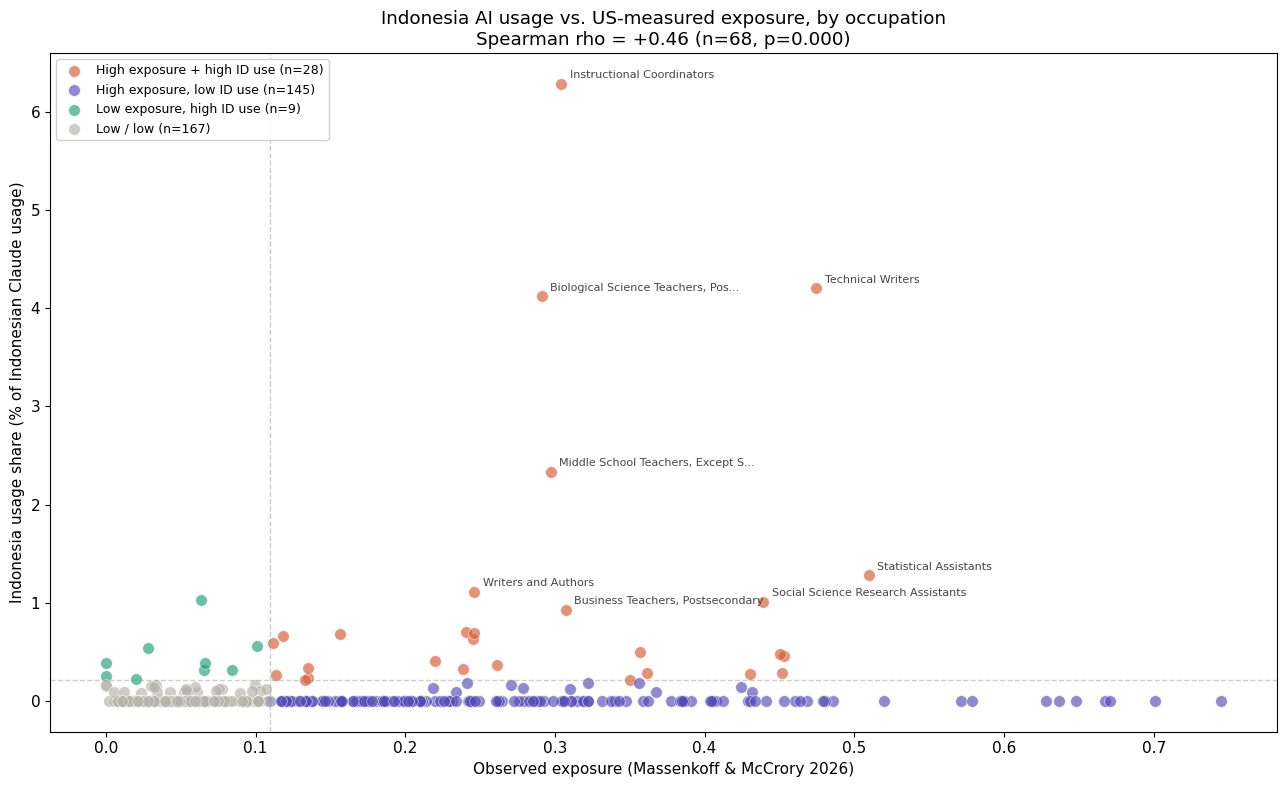

In [8]:
# The scatter
fig, ax = plt.subplots(figsize=(13, 8))

plot_df = df[(df.observed_exposure > 0) | (df.indonesia_usage_pct > 0)].copy()

# Quadrant thresholds: medians among occupations with nonzero exposure
exp_med = plot_df[plot_df.observed_exposure > 0].observed_exposure.median()
use_med = plot_df[plot_df.indonesia_usage_pct > 0].indonesia_usage_pct.median()

# Color by quadrant
def quadrant(row):
    hi_exp = row.observed_exposure >= exp_med
    hi_use = row.indonesia_usage_pct >= use_med
    return ('high_high' if hi_exp and hi_use
            else 'high_low' if hi_exp and not hi_use
            else 'low_high' if hi_use
            else 'low_low')

plot_df['quad'] = plot_df.apply(quadrant, axis=1)
colors = {'high_high': '#D85A30', 'high_low': '#534AB7', 'low_high': '#1D9E75', 'low_low': '#B4B2A9'}
labels = {'high_high': 'High exposure + high ID use (n={})',
          'high_low':  'High exposure, low ID use (n={})',
          'low_high':  'Low exposure, high ID use (n={})',
          'low_low':   'Low / low (n={})'}

for q, color in colors.items():
    sub = plot_df[plot_df.quad == q]
    ax.scatter(sub.observed_exposure, sub.indonesia_usage_pct,
               s=70, alpha=0.65, color=color, edgecolor='white', linewidth=0.5,
               label=labels[q].format(len(sub)))

# Annotate a few notable points in the high-high quadrant
hh = plot_df[plot_df.quad == 'high_high'].nlargest(8, 'indonesia_usage_pct')
for _, r in hh.iterrows():
    title_short = r.title if len(r.title) < 35 else r.title[:32] + '...'
    ax.annotate(title_short, (r.observed_exposure, r.indonesia_usage_pct),
                xytext=(6, 4), textcoords='offset points', fontsize=8, color='#444')

ax.axvline(exp_med, color='#888', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(use_med, color='#888', linestyle='--', alpha=0.4, linewidth=1)
ax.set_xlabel('Observed exposure (Massenkoff & McCrory 2026)')
ax.set_ylabel('Indonesia usage share (% of Indonesian Claude usage)')
ax.set_title(f'Indonesia AI usage vs. US-measured exposure, by occupation\n'
             f'Spearman rho = {sp_both:+.2f} (n={len(both_nonzero)}, p={sp_both_p:.3f})')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'indonesia_exposure_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. The four quadrants in detail

In [9]:
# Print the occupations in each meaningful quadrant
for q, description in [
    ('high_high', 'HIGH EXPOSURE + HIGH INDONESIAN USE  (the observable adjustment cohort)'),
    ('high_low',  'HIGH EXPOSURE + LOW INDONESIAN USE  (latent displacement risk)'),
    ('low_high',  'LOW EXPOSURE + HIGH INDONESIAN USE  (augmentation without displacement)'),
]:
    subset = plot_df[plot_df.quad == q].sort_values('indonesia_usage_pct', ascending=False)
    print(f'\n=== {description} ===')
    print(f'n = {len(subset)}\n')
    print(subset[['occ_code', 'title', 'observed_exposure', 'indonesia_usage_pct']].head(15).to_string(index=False))


=== HIGH EXPOSURE + HIGH INDONESIAN USE  (the observable adjustment cohort) ===
n = 28

occ_code                                                                 title  observed_exposure  indonesia_usage_pct
 25-9031                                            Instructional Coordinators             0.3043             6.283971
 27-3042                                                     Technical Writers             0.4747             4.203876
 25-1042                            Biological Science Teachers, Postsecondary             0.2914             4.120910
 25-2022 Middle School Teachers, Except Special and Career/Technical Education             0.2972             2.334997
 43-9111                                                Statistical Assistants             0.5099             1.281198
 27-3043                                                   Writers and Authors             0.2462             1.109262
 19-4061                                    Social Science Research Assistants

## 7. Export

In [10]:
# Save the merged dataset and summary
plot_df.to_csv(OUTPUT_DIR / 'indonesia_occupation_scatter.csv', index=False)

summary = f'''
INDONESIA AI USAGE vs. US OBSERVED EXPOSURE — KEY FINDINGS
==========================================================

Context:
  Indonesia AUI:   {id_aui:.3f}
  Global median:   {median_aui:.3f}
  Indonesia is at {id_aui / median_aui:.0%} of the global median adoption rate.

Main result:
  Spearman correlation between observed exposure and Indonesia usage share
  across occupations with both > 0 (n={len(both_nonzero)}):
    rho = {sp_both:+.3f}  (p = {sp_both_p:.4f})

Quadrant counts:
  High exposure + high ID use:  {(plot_df.quad == 'high_high').sum()}
  High exposure, low ID use:    {(plot_df.quad == 'high_low').sum()}
  Low exposure, high ID use:    {(plot_df.quad == 'low_high').sum()}

Interpretation:
  {'Positive correlation: Indonesian AI usage follows where US-measured exposure is highest.' if sp_both > 0.2 and sp_both_p < 0.05 else 'Weak/no correlation: Indonesian usage pattern diverges from US exposure pattern.' if abs(sp_both) < 0.2 else 'Negative correlation: Indonesian usage concentrates AWAY from high-exposure occupations.'}

Files exported:
  outputs/indonesia_occupation_scatter.csv
  outputs/indonesia_exposure_scatter.png
'''
print(summary)
with open(OUTPUT_DIR / 'indonesia_findings.txt', 'w') as f:
    f.write(summary)


INDONESIA AI USAGE vs. US OBSERVED EXPOSURE — KEY FINDINGS

Context:
  Indonesia AUI:   0.368
  Global median:   0.757
  Indonesia is at 49% of the global median adoption rate.

Main result:
  Spearman correlation between observed exposure and Indonesia usage share
  across occupations with both > 0 (n=68):
    rho = +0.463  (p = 0.0001)

Quadrant counts:
  High exposure + high ID use:  28
  High exposure, low ID use:    145
  Low exposure, high ID use:    9

Interpretation:
  Positive correlation: Indonesian AI usage follows where US-measured exposure is highest.

Files exported:
  outputs/indonesia_occupation_scatter.csv
  outputs/indonesia_exposure_scatter.png



## What this gives you for the thesis

**One figure, one number, one claim.**

The scatter plot is the central artifact. The Spearman rho is the headline statistic. The claim is descriptive:

*Indonesian AI usage at the occupation level correlates [positively/weakly/negatively] with US-measured AI exposure. Of the ~N US occupations with observable Indonesian Claude usage, K fall in the high-exposure + high-usage quadrant — meaning Indonesian workers in these occupations are the cohort whose labor market experience is most informative for anticipating broader AI effects.*

**Limitations to state upfront:**

- Claude usage only — other AI platforms may show different country-level patterns
- One-week snapshot (Aug 4–11, 2025) — single point, no trend
- US-measured exposure assumes task content is comparable across countries
- Tasks filtered below Anthropic's privacy threshold (rare tasks not visible)
- Indonesian employment-by-occupation counts would further refine the analysis (BPS Sakernas) but are not required for this descriptive claim

**Why this framing is defensible:**

- Two independently measured variables, no invented index
- Spearman correlation is robust to outliers and non-linear relationships
- The finding is descriptive, not prescriptive — no policy claims that outrun the data
- Extends Massenkoff & McCrory's own Figure 4 approach (exposure vs. BLS projections) by substituting Indonesian usage for the second axis